### Box Office Revenue Prediction Using Linear Regression

**1. Import the libraries**

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

**2. Load and analyze the dataset**

In [46]:
df= pd.read_csv('boxoffice.csv')
df.head()

,title,domestic_revenue,world_revenue,distributor,opening_revenue,opening_theaters,budget,MPAA,genres,release_days
0,The Avengers,6026491,1274885664,Warner Bros.,163620146,253,174687337,R,Animation,16
1,Titanic,169411543,1132871091,Disney,85549990,122,103948486,G,Action,103
2,Jurassic Park,107836098,583329845,Sony,55681429,3826,122104991,NC-17,Horror,89
3,Avatar,51433697,1225323391,Disney,109775324,3868,46431596,G,Horror,85
4,The Lion King,142791649,604140729,Warner Bros.,59476800,2934,203513696,R,Comedy,158


In [47]:
df.describe()

,domestic_revenue,world_revenue,opening_revenue,opening_theaters,budget,release_days
count,2.694000e+03,2.694000e+03,2.694000e+03,2694.000000,2.694000e+03,2694.000000
mean,1.508539e+08,7.719177e+08,9.971321e+07,2263.039347,1.537996e+08,90.897550
std,8.579997e+07,4.284414e+08,5.721762e+07,1298.559140,8.557624e+07,50.894041
min,8.277650e+05,3.261301e+06,1.385690e+05,10.000000,5.197977e+06,1.000000
25%,7.673272e+07,3.991135e+08,5.033848e+07,1161.000000,7.861876e+07,47.000000
50%,1.525725e+08,7.665551e+08,9.981418e+07,2271.500000,1.562567e+08,91.000000
75%,2.247314e+08,1.143920e+09,1.489805e+08,3392.250000,2.274832e+08,135.000000
max,2.998107e+08,1.499310e+09,1.999336e+08,4499.000000,2.998597e+08,179.000000


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2694 entries, 0 to 2693
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             2694 non-null   str  
 1   domestic_revenue  2694 non-null   int64
 2   world_revenue     2694 non-null   int64
 3   distributor       2694 non-null   str  
 4   opening_revenue   2694 non-null   int64
 5   opening_theaters  2694 non-null   int64
 6   budget            2694 non-null   int64
 7   MPAA              2694 non-null   str  
 8   genres            2694 non-null   str  
 9   release_days      2694 non-null   int64
dtypes: int64(6), str(4)
memory usage: 210.6 KB


In [49]:
df.drop(['world_revenue', 'opening_revenue'], axis=1, inplace=True)
df

,title,domestic_revenue,distributor,opening_theaters,budget,MPAA,genres,release_days
0,The Avengers,6026491,Warner Bros.,253,174687337,R,Animation,16
1,Titanic,169411543,Disney,122,103948486,G,Action,103
2,Jurassic Park,107836098,Sony,3826,122104991,NC-17,Horror,89
3,Avatar,51433697,Disney,3868,46431596,G,Horror,85
4,The Lion King,142791649,Warner Bros.,2934,203513696,R,Comedy,158
...,...,...,...,...,...,...,...,...
2689,X-Men,38153242,Disney,3532,106955513,G,Comedy,92
2690,The Matrix,63305093,Disney,3171,111238142,PG-13,Comedy,156
2691,Forrest Gump,271758510,Disney,2450,112364620,NC-17,Drama,146
2692,Jaws,268259149,Disney,661,172229703,G,Thriller,170


**3. Handling the missing data**

In [50]:
df.isnull().sum() * 100 / df.shape[0]

title               0.0
domestic_revenue    0.0
distributor         0.0
opening_theaters    0.0
budget              0.0
MPAA                0.0
genres              0.0
release_days        0.0
dtype: float64

In [51]:
df.drop('budget', axis=1, inplace=True)

for col in ['MPAA', 'genres']:
  df[col] = df[col].fillna(df[col].mode()[0])

df.dropna(inplace=True)

df.isnull().sum().sum()

np.int64(0)

**3.1 cleaning numerics columns stored as strings**

In [52]:
df['domestic_revenue'] = df['domestic_revenue'].astype(str).str[1:]

for col in ['domestic_revenue', 'opening_theaters', 'release_days']:
  df[col] = df[col].astype(str).str.replace({',':''})

  temp = (~df[col].isnull())
  df[temp][col] = df[temp][col].convert_dtypes(float)

  df[col] = pd.to_numeric(df[col], errors='coerce')

**4. Some features visualization**

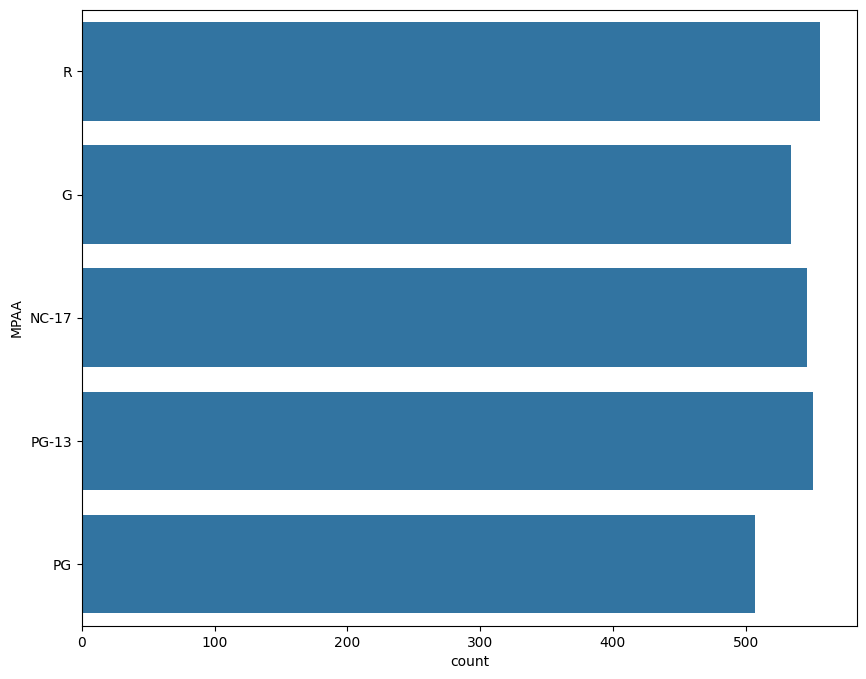

In [53]:
plt.figure(figsize=(10, 8))
sns.countplot(df['MPAA'])
plt.show()

In [54]:
df.groupby('MPAA')['domestic_revenue'].mean()

MPAA
G        3.426099e+07
NC-17    3.452006e+07
PG       3.697347e+07
PG-13    3.510989e+07
R        3.670206e+07
Name: domestic_revenue, dtype: float64

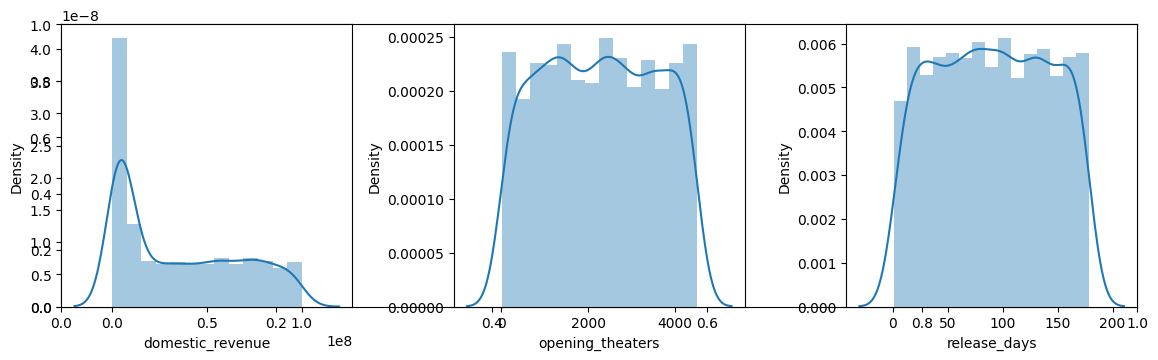

In [55]:
plt.subplots(figsize=(12, 4))

features = ['domestic_revenue', 'opening_theaters', 'release_days']
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.distplot(df[col])
plt.tight_layout()
plt.show()

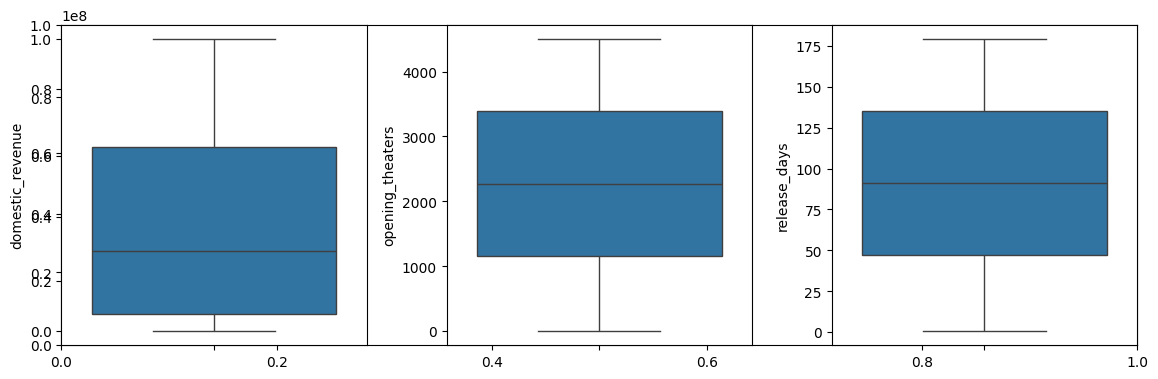

In [56]:
plt.subplots(figsize=(12, 4))

features = ['domestic_revenue', 'opening_theaters', 'release_days']
for i, col in enumerate(features):
  plt.subplot(1, 3, i+1)
  sns.boxplot(df[col])
plt.tight_layout()
plt.show()

**5.Applying log-loss and visualizing after**

In [57]:
for col in features:
  df[col] = df[col].apply(lambda x : np.log10(x))

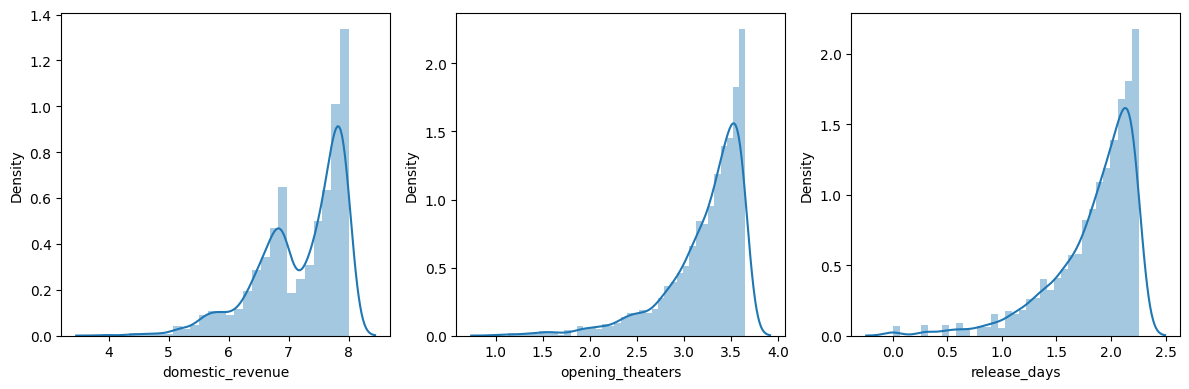

In [58]:
plt.figure(figsize=(12, 4))

for i, col in enumerate(features):
  plt.subplot(1, 3, i+1)
  sns.distplot(df[col])
plt.tight_layout()
plt.show()

**6. Converting movie number into numeric features**

In [59]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
vectorizer.fit(df['genres'])
features = vectorizer.transform(df['genres']).toarray()

genres = vectorizer.get_feature_names_out()
for i, name in enumerate(genres):
  df[name] = features[:,i]

df.drop('genres', axis=1, inplace=True)

**6.1 Removing Rare Genre Columns with Mostly Zero Values**

In [60]:
removed = 0

if 'action' in df.columns and 'western' in df.columns:
  for col in df.iloc[:, 'action':'western'].columns:

    if (df[col] == 0).mean() > 0.95:
      removed += 1
      df.drop(df[col], axis=1, inplace=True)

**7. Encoding categorical columns into numbers**

In [61]:
for col in ['distributor', 'MPAA']:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])

**8. Visualizing correlation between numeric features**

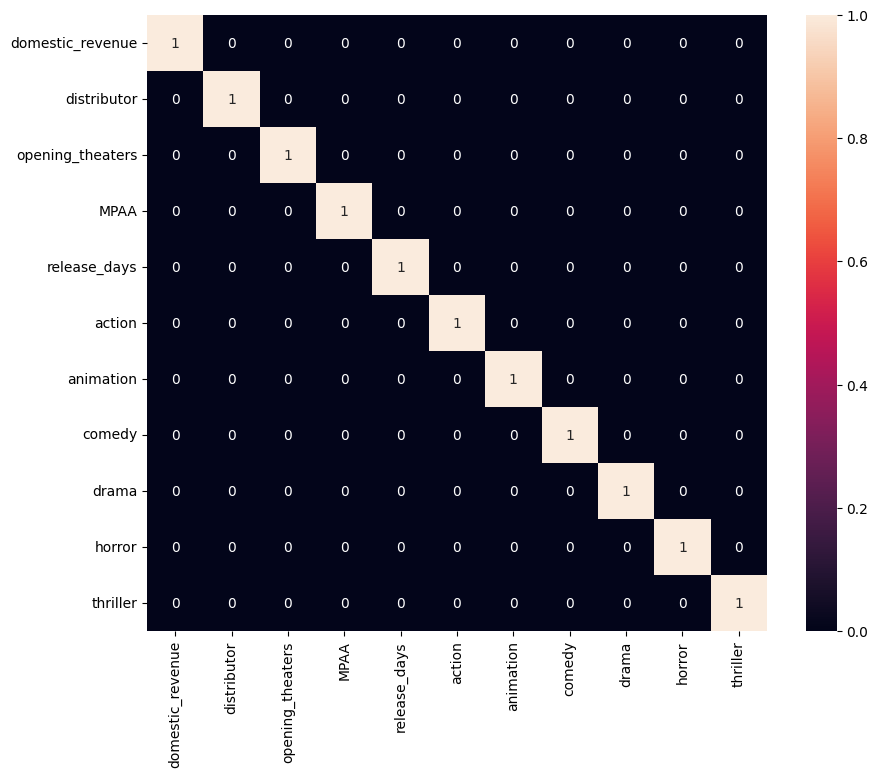

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(
  df.select_dtypes(include=np.number).corr() > 0.8,
  annot=True,
  cbar=True
)
plt.show()

**9. Preparing the data for modeling**

In [63]:
feature = df.drop(['title', 'domestic_revenue'], axis=1)
target = df['domestic_revenue'].values

X_train, X_test, y_train, y_test = train_test_split(
  feature, target,
  test_size=0.25, random_state=42
)

X_train.shape, y_train.shape

((2020, 10), (2020,))

In [64]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**10. Train the XGBoost model**

In [65]:
model = XGBRegressor()
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [66]:
from sklearn.metrics import mean_absolute_error as mae

train_pred = model.predict(X_train)
print("Training Error: ", mae(y_train, train_pred))

Training Error:  0.1681566844989731


In [67]:
org_preds = model.predict(X_test)
print("Validation Error: ", mae(y_test, org_preds))
print()

Validation Error:  0.6590575911286505

